In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import least_squares
import yfinance as yf
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (14, 6), "font.size": 12})

### Step 1

In [4]:
raw = pd.read_csv("option20230201_20230228.csv")
print(f"Raw rows: {len(raw)}")

df = raw[raw["cp_flag"] == "C"].copy()
print(f"After applying filter (for calls): {len(df)}")

df["date"] = pd.to_datetime(df["date"])
df["exdate"] = pd.to_datetime(df["exdate"])
df["K"] = df["strike_price"] / 1000
df["mid"] = (df["best_bid"] + df["best_offer"]) / 2

n = len(df)
print(f"\nMissing rates:")
print(f"  Vt (mid):   {df['mid'].isna().sum()}/{n} ({100*df['mid'].isna().sum()/n:.2f}%)")
print(f"  σ_mkt (IV): {df['impl_volatility'].isna().sum()}/{n} ({100*df['impl_volatility'].isna().sum()/n:.2f}%)")
print(f"  delta:      {df['delta'].isna().sum()}/{n} ({100*df['delta'].isna().sum()/n:.2f}%)")

df = df.dropna(subset=["impl_volatility", "delta"])
print(f"After dropping missing IV/delta: {len(df)}")

df["D"] = (df["exdate"] - df["date"]).dt.days
df["tau"] = df["D"] / 365

keep = ["date", "exdate", "symbol", "K", "mid", "impl_volatility",
        "delta", "best_bid", "best_offer", "D", "tau"]
df = df[keep].copy()

print(f"\nUnique trading dates: {df['date'].nunique()}")
print(f"Unique expiries: {df['exdate'].nunique()}")
print(f"Final columns: {list(df.columns)}")

Raw rows: 175301
After applying filter (for calls): 175301

Missing rates:
  Vt (mid):   0/175301 (0.00%)
  σ_mkt (IV): 21573/175301 (12.31%)
  delta:      21573/175301 (12.31%)
After dropping missing IV/delta: 153728

Unique trading dates: 19
Unique expiries: 67
Final columns: ['date', 'exdate', 'symbol', 'K', 'mid', 'impl_volatility', 'delta', 'best_bid', 'best_offer', 'D', 'tau']


### Step 2

In [5]:
df = df.sort_values(["symbol", "date"])
df["mid_next"] = df.groupby("symbol")["mid"].shift(-1)
df["dV"] = df["mid_next"] - df["mid"]

n_before = len(df)
df = df.dropna(subset=["dV"])

print(f"\nRows with valid ΔVt: {len(df)} (dropped {n_before - len(df)})")
print(f"Contracts retained: {df['symbol'].nunique()}")
print(f"\nVt summary:\n{df['mid'].describe().to_string()}")
print(f"\nΔVt summary:\n{df['dV'].describe().to_string()}")


Rows with valid ΔVt: 141619 (dropped 12109)
Contracts retained: 11593

Vt summary:
count    141619.000000
mean        430.754198
std         578.585187
min           0.025000
25%          36.400000
50%         206.450000
75%         600.850000
max        4022.700000

ΔVt summary:
count    141619.000000
mean         -6.315655
std          27.128320
min        -170.300000
25%         -22.200000
50%          -2.150000
75%           5.100000
max          70.200000


### Step 3

[*********************100%***********************]  1 of 1 completed


SPX trading days: 21

St summary:
count      21.000000
mean     4068.892846
std        74.859970
min      3951.389893
25%      3991.050049
50%      4090.409912
75%      4136.129883
max      4179.759766

ΔSt summary:
count    20.000000
mean     -6.892993
std      38.249929
min     -81.750000
25%     -37.839905
50%      -8.804932
75%      14.467468
max      60.549805


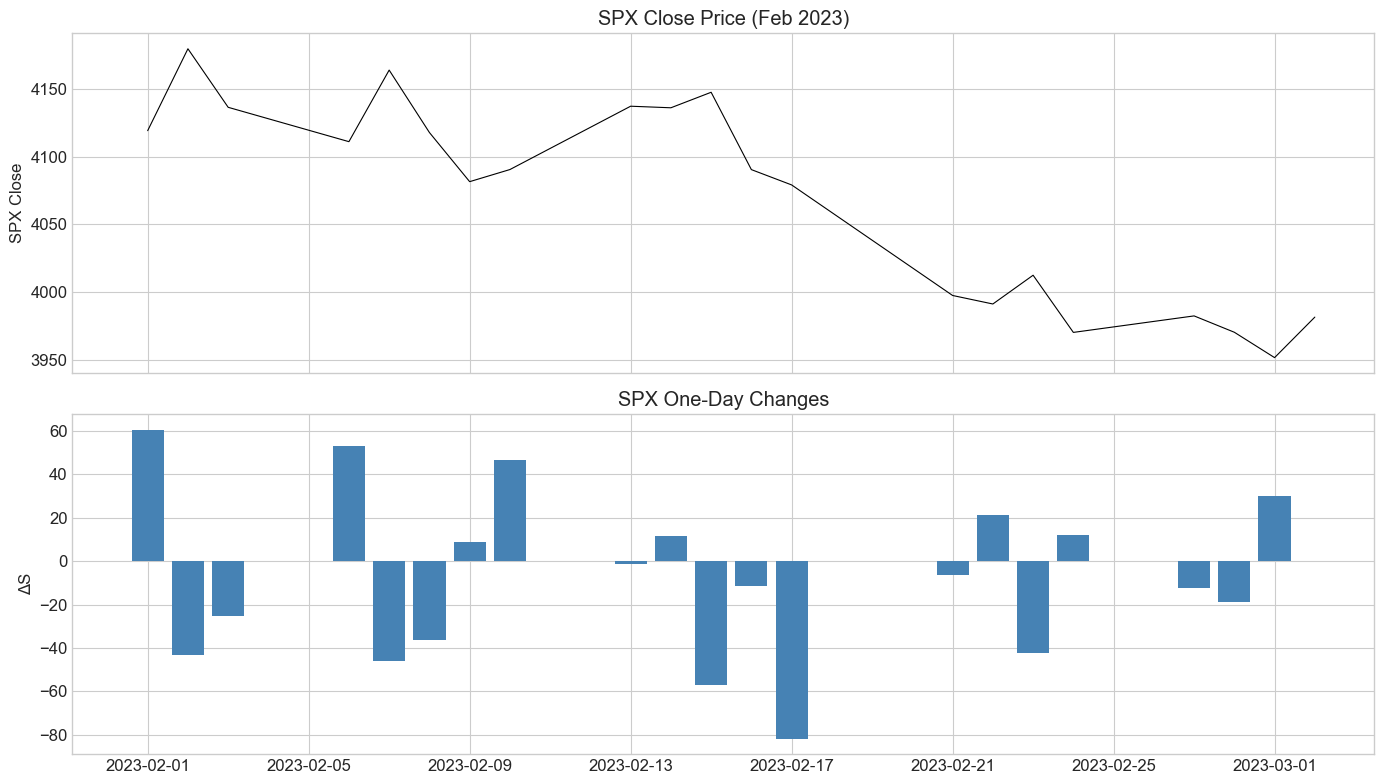


Merge coverage: 141619/141619 (100.0%)
After dropping unmatched: 141619


In [7]:
spx = yf.download("^GSPC", start="2023-02-01", end="2023-03-03")

if isinstance(spx.columns, pd.MultiIndex):
    spx.columns = spx.columns.get_level_values(0)
    
spx = spx[["Close"]].rename(columns={"Close": "S"})
spx.index = pd.to_datetime(spx.index)
spx.index.name = "date"
spx["dS"] = spx["S"].shift(-1) - spx["S"]

print(f"\nSPX trading days: {len(spx)}")
print(f"\nSt summary:\n{spx['S'].describe().to_string()}")
print(f"\nΔSt summary:\n{spx['dS'].describe().to_string()}")

fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
ax[0].plot(spx.index, spx["S"], color="black", lw=0.8)
ax[0].set_ylabel("SPX Close")
ax[0].set_title("SPX Close Price (Feb 2023)")
ax[1].bar(spx.index, spx["dS"], color="steelblue", width=0.8)
ax[1].set_ylabel("ΔS")
ax[1].set_title("SPX One-Day Changes")
plt.tight_layout()
plt.savefig("step3_spx.png", dpi=150)
plt.show()

df = df.merge(spx[["S", "dS"]], left_on="date", right_index=True, how="left")
total = len(df)
matched = df["S"].notna().sum()
print(f"\nMerge coverage: {matched}/{total} ({100*matched/total:.1f}%)")
df = df.dropna(subset=["S", "dS"])
print(f"After dropping unmatched: {len(df)}")



### Step 4

In [20]:
tenor_names = ["1 mo","2 mo","3 mo","4 mo","6 mo","1 yr","2 yr","3 yr","5 yr","7 yr","10 yr","20 yr","30 yr"]
tenor_yrs = np.array([1/12, 2/12, 3/12, 4/12, 6/12,1, 2, 3, 5, 7, 10, 20, 30])

In [21]:
tsy_url = (
        "https://home.treasury.gov/resource-center/data-chart-center/"
        "interest-rates/daily-treasury-rate-archives/"
        "par-yield-curve-rates-2020-2023.csv"
    )
tsy = pd.read_csv(tsy_url)
tsy["date"] = pd.to_datetime(tsy["date"]).dt.normalize()
    
tsy = tsy[(tsy["date"] >= "2023-01-25") & (tsy["date"] <= "2023-03-03")]
tsy = tsy.set_index("date").sort_index()
   
tenor_cols = [c for c in tenor_names if c in tsy.columns]
tenor_vals = np.array([tenor_yrs[tenor_names.index(c)] for c in tenor_cols])
print(f"\nLoaded Treasury data from URL, {len(tsy)} rows")


Loaded Treasury data from URL, 27 rows


In [38]:
opt_dates = sorted(df["date"].unique())
full_idx = pd.date_range(tsy.index.min(), pd.Timestamp("2023-03-03"))
tsy = tsy.reindex(full_idx, method="ffill")

In [40]:
def nss_g1(tau, lam):
    x = tau/lam
    return np.where(x<1e-8, 1, (1-np.exp(-x))/x)

def nss_g2(tau, lam):
    return nss_g1(tau, lam) - np.exp(-tau/lam)

def nss_g3(tau, lam):
    x = tau/lam
    return np.where(x < 1e-8, 1, (1 - np.exp(-x))/x) - np.exp(-tau/lam)

def fit_nss(tenors, yields):
    best_sse, best = np.inf, None
    for t1 in np.linspace(0.1, 5, 30):
        for t2 in np.linspace(0.1, 10, 30):
            if t2 < t1:
                continue
            X = np.column_stack([
                np.ones(len(tenors)),
                nss_g1(tenors, t1),
                nss_g2(tenors, t1),
                nss_g3(tenors, t2)
            ])
            b = np.linalg.lstsq(X, yields, rcond=None)[0]
            sse = np.sum((yields - X @ b)**2)
            if sse < best_sse:
                best_sse, best = sse, (b, t1, t2)
    return best

def eval_nss(tau, b, t1, t2):
    tau = np.maximum(tau, 1/365)
    return b[0] + b[1]*nss_g1(tau,t1) + b[2]*nss_g2(tau,t1) + b[3]*nss_g3(tau,t2)

def par_to_cc(y):
    return 2*np.log(1 + y/2)

# Fitting NSS per trading date
nss_params = {}
for dt in opt_dates:
    dt_ts = pd.Timestamp(dt)
    if dt_ts in tsy.index:
        row = tsy.loc[dt_ts, tenor_cols].values.astype(float)
        if not np.any(np.isnan(row)):
            nss_params[dt_ts] = fit_nss(tenor_vals, row / 100)

print(f"NSS fitted for {len(nss_params)}/{len(opt_dates)} dates")


NSS fitted for 18/18 dates


In [41]:
df["r"] = 0.0
for dt in df["date"].unique():
    dt_ts = pd.Timestamp(dt)
    mask = df["date"] == dt
    if dt_ts in nss_params:
        b, t1, t2 = nss_params[dt_ts]
        taus = np.maximum(df.loc[mask, "tau"].values, 1/365)
        y = eval_nss(taus, b, t1, t2)
        df.loc[mask, "r"] = par_to_cc(y)

df["disc"] = np.exp(-df["r"] * df["tau"])
df["fwd"] = df["S"] * np.exp(df["r"] * df["tau"])

print(f"\nrt(τ) summary:")
print(f"  min    = {df['r'].min():.5f}")
print(f"  median = {df['r'].median():.5f}")
print(f"  max    = {df['r'].max():.5f}")
all_finite_r = df["r"].notna().all() and np.isfinite(df["r"]).all()
all_finite_d = df["disc"].notna().all() and np.isfinite(df["disc"]).all()
print(f"  All rt(τ) finite: {all_finite_r}")
print(f"  All Pt(τ) finite: {all_finite_d}")


rt(τ) summary:
  min    = 0.03439
  median = 0.04664
  max    = 0.05076
  All rt(τ) finite: True
  All Pt(τ) finite: True


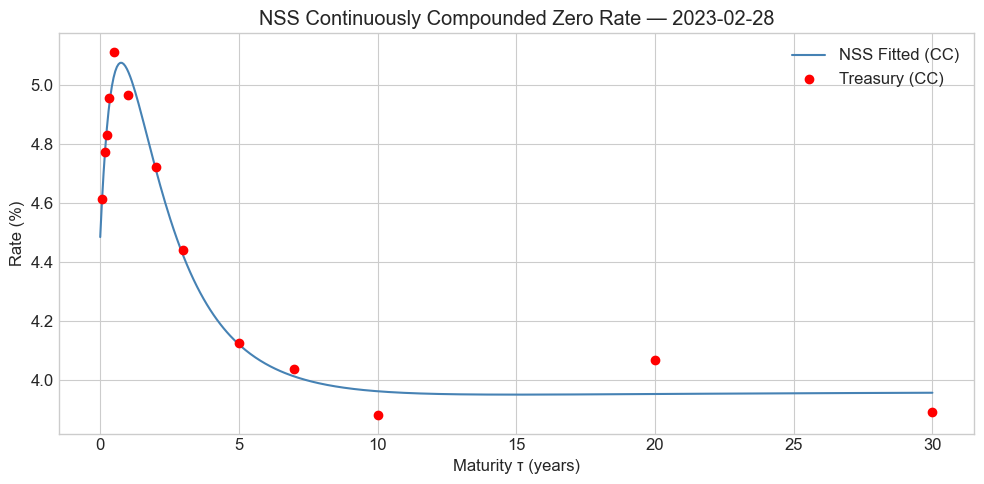

In [43]:
rep = pd.Timestamp("2023-02-28")
row_28 = tsy.loc[rep, tenor_cols].values.astype(float) / 100.0
b, t1, t2 = fit_nss(tenor_vals, row_28)

tau_plot = np.linspace(1/365, 30, 500)
r_plot = par_to_cc(eval_nss(tau_plot, b, t1, t2))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tau_plot, r_plot * 100, color="steelblue", lw=1.5, label="NSS Fitted (CC)")
ax.scatter(tenor_vals, par_to_cc(row_28) * 100, color="red", zorder=5, label="Treasury (CC)")
ax.set_xlabel("Maturity τ (years)")
ax.set_ylabel("Rate (%)")
ax.set_title(f"NSS Continuously Compounded Zero Rate — {rep.date()}")
ax.legend()
plt.tight_layout()
plt.savefig("step4_nss.png", dpi=150)
plt.show()

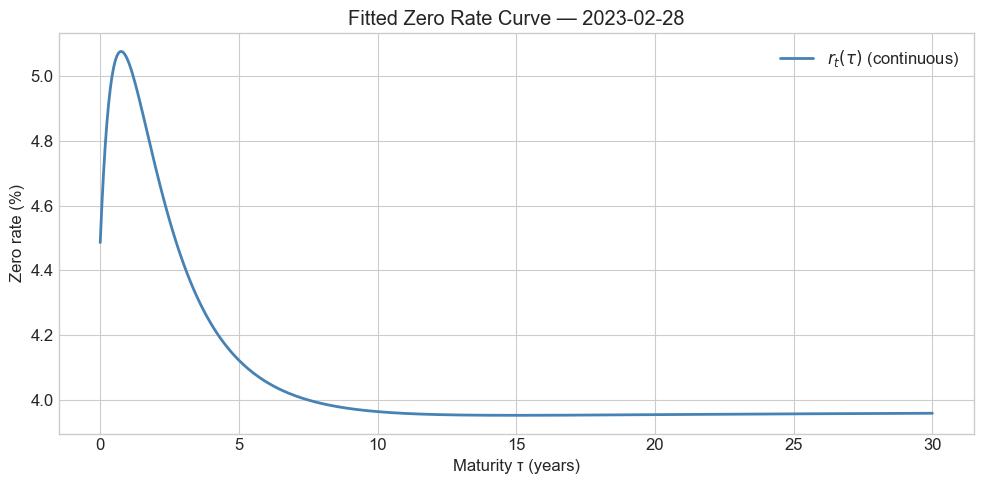

In [83]:
rep = pd.Timestamp("2023-02-28")
row_28 = tsy.loc[rep, tenor_cols].values.astype(float) / 100.0
b, t1, t2 = fit_nss(tenor_vals, row_28)

tau_plot = np.linspace(1/365, 30, 500)
r_plot = par_to_cc(eval_nss(tau_plot, b, t1, t2))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tau_plot, r_plot * 100, color="steelblue", lw=2, label=r"$r_t(\tau)$ (continuous)")
ax.set_xlabel("Maturity τ (years)")
ax.set_ylabel("Zero rate (%)")
ax.set_title(f"Fitted Zero Rate Curve — {rep.date()}")
ax.legend()
plt.tight_layout()
plt.savefig("step4_zero_rate.png", dpi=150)
plt.show()

### Step 5

In [62]:
df["delta_bs"] = df["delta"]
df["eps"] = df["dV"] - df["delta_bs"] * df["dS"]
print(f"\nResidual stats (before filters):")
print(df["eps"].describe().to_string())



Residual stats (before filters):
count    141619.000000
mean         -0.990743
std           9.948982
min        -170.647819
25%          -2.652592
50%          -0.083390
75%           1.738535
max          98.468194


In [64]:
n0 = len(df)
df_f = df[df["delta_bs"] > 0.05].copy()
n1 = len(df_f)
df_f = df_f[df_f["delta_bs"] < 0.95]
n2 = len(df_f)
df_f = df_f[df_f["D"] > 14]
n3 = len(df_f)

print(f"\nFilter steps:")
print(f"  Start:              {n0}")
print(f"  After Δ > 0.05:     {n1} (removed {n0-n1})")
print(f"  After Δ < 0.95:     {n2} (removed {n1-n2})")
print(f"  After D > 14:       {n3} (removed {n2-n3})")

df_f["eps"] = df_f["dV"] - df_f["delta_bs"] * df_f["dS"]


Filter steps:
  Start:              141619
  After Δ > 0.05:     121799 (removed 19820)
  After Δ < 0.95:     98720 (removed 23079)
  After D > 14:       87880 (removed 10840)


In [67]:
sse_bs = (df_f["eps"]**2).sum()
mse_bs = (df_f["eps"]**2).mean()
print(f"\nSSE(ΔBS) = {sse_bs:.2f}")
print(f"MSE(ΔBS) = {mse_bs:.6f}")


SSE(ΔBS) = 1015068.74
MSE(ΔBS) = 11.550623


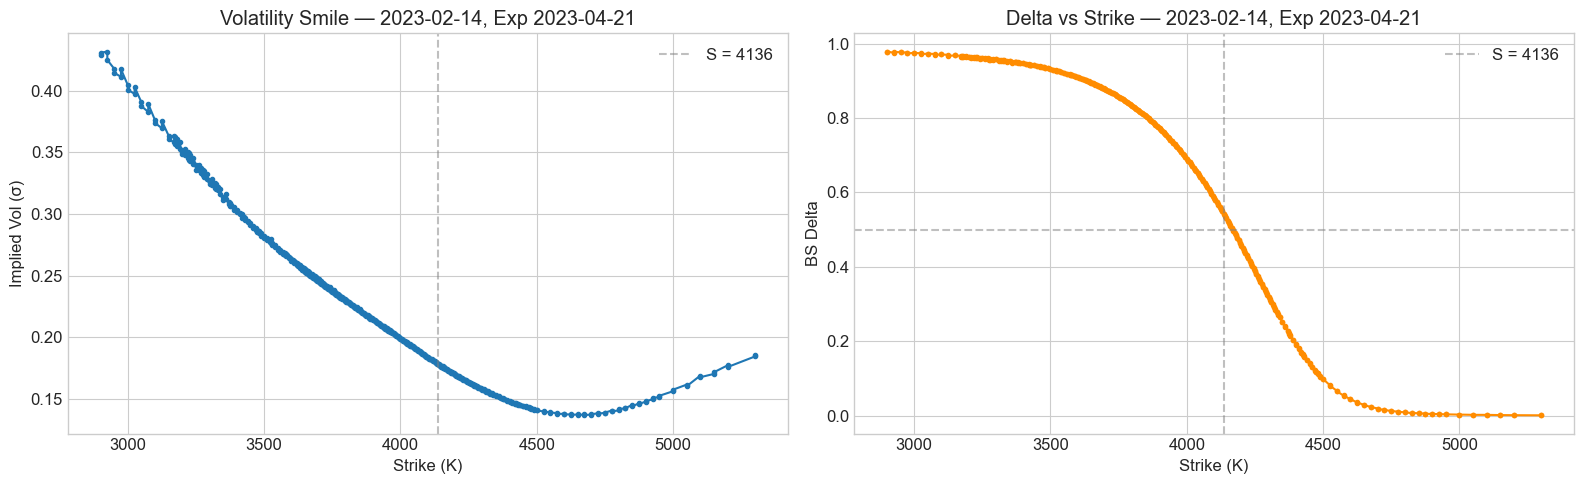

In [81]:
sample_dt = sorted(df_f["date"].unique())[len(df_f["date"].unique())//2]
exp_counts = df_f[df_f["date"]==sample_dt]["exdate"].value_counts()
sample_exp = exp_counts.idxmax()
sl = df[(df["date"]==sample_dt) & (df["exdate"]==sample_exp)].sort_values("K")

S_t = df[df["date"]==sample_dt]["S"].iloc[0]
sl = sl[(sl["K"] > 0.7 * S_t) & (sl["K"] < 1.3 * S_t)]

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(sl["K"], sl["impl_volatility"], "o-", ms=3)
ax[0].axvline(S_t, color="gray", ls="--", alpha=0.5, label=f"S = {S_t:.0f}")
ax[0].set_xlabel("Strike (K)")
ax[0].set_ylabel("Implied Vol (σ)")
ax[0].set_title(f"Volatility Smile — {sample_dt.date()}, Exp {sample_exp.date()}")
ax[0].legend()

ax[1].plot(sl["K"], sl["delta_bs"], "o-", ms=3, color="darkorange")
ax[1].axhline(0.5, color="gray", ls="--", alpha=0.5)
ax[1].axvline(S_t, color="gray", ls="--", alpha=0.5, label=f"S = {S_t:.0f}")
ax[1].set_xlabel("Strike (K)")
ax[1].set_ylabel("BS Delta")
ax[1].set_title(f"Delta vs Strike — {sample_dt.date()}, Exp {sample_exp.date()}")
ax[1].legend()

plt.tight_layout()
plt.savefig("step5_smile_delta.png", dpi=150)
plt.show()

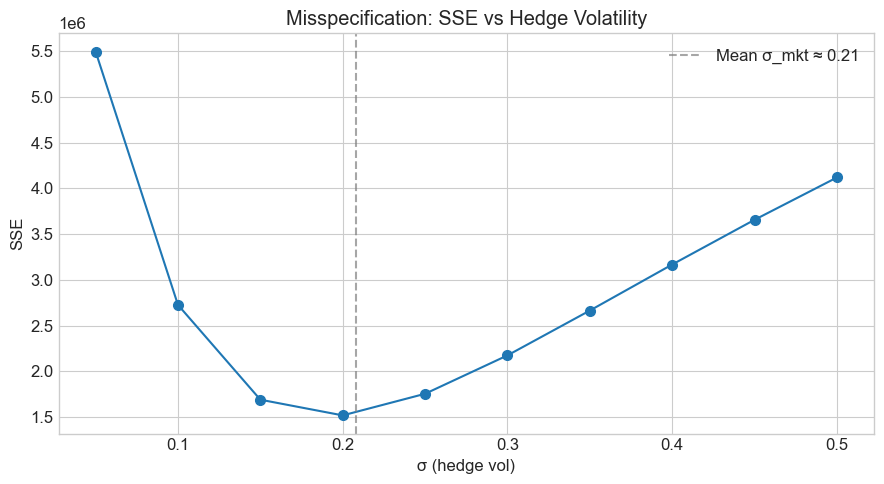

In [70]:
def bs_d(F, K, tau, sig):
    tau = np.maximum(tau, 1/365)
    d1 = (np.log(F/K) + 0.5 * sig**2 * tau) / (sig * np.sqrt(tau))
    return norm.cdf(d1)


df_f["fwd"] = df_f["S"] * np.exp(df_f["r"] * df_f["tau"])

sig_grid = np.arange(0.05, 0.55, 0.05)
sse_mis = []
for sig in sig_grid:
    d_adj = bs_d(df_f["fwd"].values, df_f["K"].values,
                 df_f["tau"].values, sig)
    e = df_f["dV"].values - d_adj * df_f["dS"].values
    sse_mis.append((e**2).sum())

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sig_grid, sse_mis, "o-", ms=7)
ax.axvline(df_f["impl_volatility"].mean(), color="gray", ls="--", alpha=0.7,
           label=f"Mean σ_mkt ≈ {df_f['impl_volatility'].mean():.2f}")
ax.set_xlabel("σ (hedge vol)")
ax.set_ylabel("SSE")
ax.set_title("Misspecification: SSE vs Hedge Volatility")
ax.legend()
plt.tight_layout()
# plt.savefig("step5_misspec.png", dpi=150)
plt.show()

In [73]:
delta_bins = np.linspace(0.05, 0.95, 10)
d_lo, d_hi = df_f["D"].min(), df_f["D"].max()
mat_bins = np.linspace(d_lo, d_hi, 8)

df_f["money_bin"] = pd.cut(df_f["delta_bs"], bins=delta_bins, labels=range(9), include_lowest=True)
df_f["mat_bin"] = pd.cut(df_f["D"], bins=mat_bins, labels=range(7), include_lowest=True)

bucket = df_f.groupby(["money_bin", "mat_bin"], observed=False).agg(
    sse=("eps", lambda x: (x**2).sum()),
    n=("eps", "count"),
    mean_delta=("delta_bs", "mean")
).reset_index()
bucket["mse"] = bucket["sse"] / bucket["n"].replace(0, np.nan)

print(f"\nBuckets with data: {(bucket['n']>0).sum()}/63")
print(f"\nBucket counts:")
count_piv = bucket.pivot_table(index="money_bin", columns="mat_bin", values="n")
print(count_piv.to_string())
print(f"\nTotal rows in buckets: {bucket['n'].sum()}")


Buckets with data: 54/63

Bucket counts:
mat_bin          0       1      2    3      4      5      6
money_bin                                                  
0           5386.0   661.0  111.0  0.0   96.0  127.0   78.0
1           4956.0   525.0   61.0  0.0   83.0   68.0   59.0
2           5185.0   632.0   47.0  0.0   61.0   77.0   47.0
3           5646.0   727.0   45.0  0.0   58.0   71.0   42.0
4           6360.0   861.0   46.0  0.0   64.0   73.0   44.0
5           7358.0  1081.0   54.0  0.0   69.0   84.0   79.0
6           8979.0  1352.0   71.0  0.0   80.0   95.0  112.0
7          11782.0  1914.0   91.0  0.0   94.0  103.0  151.0
8          17851.0  3464.0  132.0  0.0  125.0  225.0  237.0

Total rows in buckets: 87880


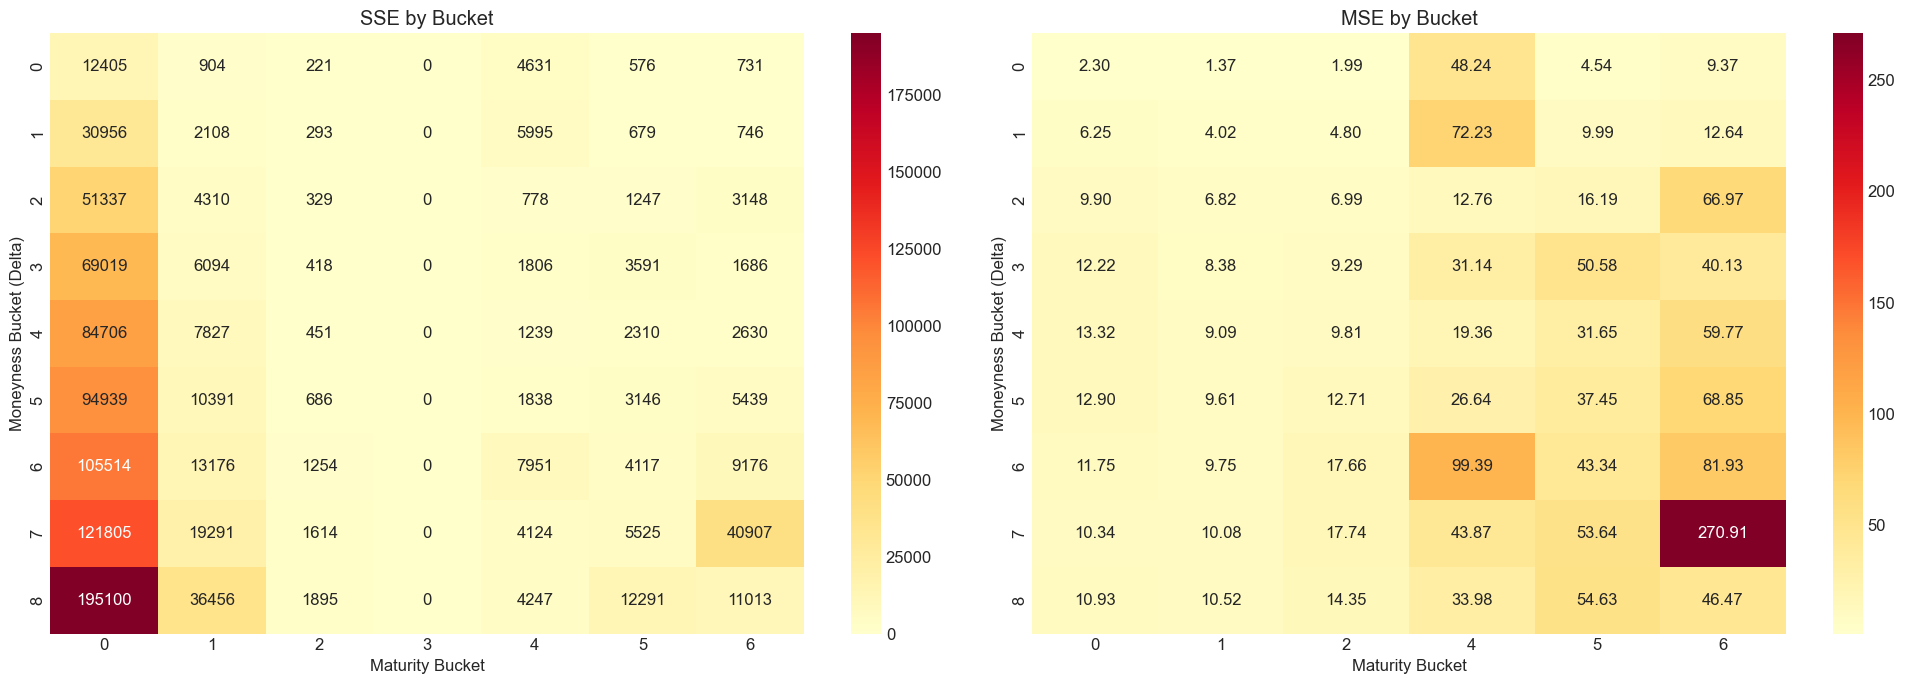

In [79]:
sse_piv = bucket.pivot_table(index="money_bin", columns="mat_bin", values="sse")
mse_piv = bucket.pivot_table(index="money_bin", columns="mat_bin", values="mse")

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

sns.heatmap(sse_piv, annot=True, fmt=".0f", cmap="YlOrRd", ax=axes[0])
axes[0].set_xlabel("Maturity Bucket")
axes[0].set_ylabel("Moneyness Bucket (Delta)")
axes[0].set_title("SSE by Bucket")

sns.heatmap(mse_piv, annot=True, fmt=".2f", cmap="YlOrRd", ax=axes[1])
axes[1].set_xlabel("Maturity Bucket")
axes[1].set_ylabel("Moneyness Bucket (Delta)")
axes[1].set_title("MSE by Bucket")

plt.tight_layout()
plt.savefig("step5_heatmaps.png", dpi=150)
plt.show()

### Step 7

In [ ]:
total_row = pd.DataFrame([{
    "money_bin": "TOTAL", "mat_bin": "TOTAL",
    "SSE": sse_bs, "MSE": mse_bs,
    "n": len(df_f), "mean_delta": df_f["delta_bs"].mean()
}])

bkt_exp = bucket[["money_bin", "mat_bin", "sse", "mse", "n", "mean_delta"]].copy()
bkt_exp.columns = ["money_bin", "mat_bin", "SSE", "MSE", "n", "mean_delta"]

scoreboard = pd.concat([total_row, bkt_exp], ignore_index=True)
scoreboard.to_csv("HedgingScoreboard.csv", index=False)
print(f"\nSaved HedgingScoreboard.csv ({len(scoreboard)} rows)")
print(f"\n  SSE: {sse_bs:,.2f} | MSE: {mse_bs:.4f} | n: {len(df_f):,}")
print(f"\nScoreboard preview:")
print(scoreboard.head(10).to_string())
####################################################################
out_cols = ["date", "exdate", "symbol", "K", "mid", "impl_volatility",
            "delta_bs", "D", "tau", "S", "dS", "dV", "r", "disc", "fwd", "eps"]
df_f[out_cols].to_csv("CleanedOptionPanel.csv", index=False)
print(f"Saved CleanedOptionPanel.csv ({len(df_f)} rows)")


Saved HedgingScoreboard.csv (64 rows)

  SSE: 1,015,068.74 | MSE: 11.5506 | n: 87,880

Scoreboard preview:
  money_bin mat_bin           SSE        MSE      n  mean_delta
0     TOTAL   TOTAL  1.015069e+06  11.550623  87880    0.614559
1         0       0  1.240510e+04   2.303212   5386    0.097692
2         0       1  9.039518e+02   1.367552    661    0.094712
3         0       2  2.206398e+02   1.987746    111    0.093342
4         0       3  0.000000e+00        NaN      0         NaN
5         0       4  4.631357e+03  48.243305     96    0.092613
6         0       5  5.762957e+02   4.537762    127    0.090393
7         0       6  7.309910e+02   9.371680     78    0.089565
8         1       0  3.095612e+04   6.246190   4956    0.200324
9         1       1  2.108210e+03   4.015639    525    0.200796
Saved CleanedOptionPanel.csv (87880 rows)
